# Emotional Intelligence and Trust in Agentic AI
## A Python-Based Statistical and Behavioral Analytics Project

| Attribute | Details |
| --- | --- |
| **Author** | Rutuja Shinde |
| **Project** | Emotional Intelligence vs AI Trust Analysis |
| **Role** | Behavioral Data Analyst |
| **Date** | May 2026 |

---

### Project Overview
As conversational and agentic AI systems become integrated into daily workflows, trust is no longer just a technical assessment of accuracy, but an emotional and relational evaluation. This project analyzes how user Emotional Intelligence (EI) relates to trust, perceived empathy, emotional reliance, and comfort during AI interactions. 

The analysis is structured around behavioral analytics, psychometric validation, hypothesis testing, linear regression, bootstrap mediation modeling, and user segmentation.


## Research Questions and Hypotheses

1. **Question 1**: Is a user's Emotional Intelligence (EI) associated with their trust in Agentic AI?
   - *Null Hypothesis (H0)*: There is no correlation between EI score and Trust score.
   - *Alternative Hypothesis (H1)*: There is a statistically significant correlation between EI score and Trust score.
2. **Question 2**: Does perceived empathy explain the mechanism of this relationship?
   - *Hypothesis*: Perceived empathy mediates the relationship between Emotional Intelligence and Trust.
3. **Question 3**: Does trust in AI differ across demographic groups or AI usage patterns?
   - *Hypothesis*: Users with higher daily AI usage exhibit significantly higher trust due to familiarity.
4. **Question 4**: Can we segment users into meaningful behavioral trust profiles?
   - *Hypothesis*: K-Means clustering will reveal distinct profiles characterized by different levels of EI, reliance, and trust.


In [1]:
import sys
import os

# Establish project root directory path
current_dir = os.path.abspath(os.getcwd())
if os.path.basename(current_dir) == "notebook":
    project_root = os.path.abspath(os.path.join(current_dir, ".."))
else:
    project_root = current_dir

# Add project root to sys.path to import src modules
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Import modular project code
from src.data_processing import load_data, clean_data, calculate_composite_scores, calculate_cronbach_alpha
from src.analysis import run_correlation, run_t_test, run_anova, perform_kmeans
from src.modeling import fit_regression, run_mediation

# Configuration
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (9, 6)})


## Data Loading and Diagnostics

We begin by loading the survey dataset (n=500). Diagnostics are conducted to ensure data cleanliness:
- Checking and removing duplicate records.
- Summarizing missing values.
- Calculating row-wise composite scores for the psychometric scales.


In [2]:
# Load data using modular script and robust project root path
csv_path = os.path.join(project_root, "synthetic_ei_ai_trust_data.csv")
df_raw = load_data(csv_path)

# Clean data and inspect missingness/duplicates
df, duplicates, missing_summary = clean_data(df_raw)
df = calculate_composite_scores(df)

print(f"Dataset shape: {df.shape}")
print(f"Duplicate records found: {duplicates}")
print("\nMissing values summary (top 5 variables):")
print(missing_summary.sort_values(ascending=False).head(5))


Dataset shape: (500, 38)
Duplicate records found: 0

Missing values summary (top 5 variables):
COMFORT2     9
COMFORT1     7
RELIANCE2    7
EI8          6
EMPATHY5     6
dtype: int64


## Descriptive Statistics

Summary statistics are computed for age and the composite scores to understand the distribution center, spread, and range of our sample.


In [3]:
score_cols = ["ei_score", "trust_score", "perceived_empathy_score", "emotional_reliance_score", "comfort_score"]
df[["age"] + score_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,500.0,24.848000,5.007499,18.000000,20.750000,24.000000,29.000000,35.0
ei_score,500.0,3.413861,0.566756,1.700000,3.100000,3.400000,3.800000,5.0
trust_score,500.0,3.770733,0.682324,1.333333,3.333333,3.833333,4.333333,5.0
perceived_empathy_score,500.0,3.454600,0.653148,1.000000,3.000000,3.400000,4.000000,5.0
emotional_reliance_score,500.0,4.048667,0.646956,1.250000,3.666667,4.000000,4.500000,5.0
comfort_score,500.0,3.947000,0.669102,1.333333,3.625000,4.000000,4.333333,5.0


## Scale Reliability (Cronbach's Alpha)

Before using composite scores in hypotheses testing, we must validate their internal reliability. Cronbach's Alpha is calculated for each psychometric construct. An Alpha above 0.70 is standard for exploratory research, while values above 0.80 indicate strong consistency.


In [4]:
# Extract items for each scale
ei_alpha = calculate_cronbach_alpha(df[[f"EI{i}" for i in range(1, 11)]])
trust_alpha = calculate_cronbach_alpha(df[[f"TRUST{i}" for i in range(1, 7)]])
empathy_alpha = calculate_cronbach_alpha(df[[f"EMPATHY{i}" for i in range(1, 6)]])
reliance_alpha = calculate_cronbach_alpha(df[[f"RELIANCE{i}" for i in range(1, 5)]])
comfort_alpha = calculate_cronbach_alpha(df[[f"COMFORT{i}" for i in range(1, 4)]])

reliability = pd.DataFrame({
    "Construct": ["Emotional Intelligence", "Trust in AI", "Perceived Empathy", "Emotional Reliance", "Comfort"],
    "Number of Items": [10, 6, 5, 4, 3],
    "Cronbach Alpha": [ei_alpha, trust_alpha, empathy_alpha, reliance_alpha, comfort_alpha]
})
reliability


,Construct,Number of Items,Cronbach Alpha
0,Emotional Intelligence,10,0.871049
1,Trust in AI,6,0.879761
2,Perceived Empathy,5,0.800252
3,Emotional Reliance,4,0.791084
4,Comfort,3,0.725463


## Exploratory Data Analysis

We visualize the distribution of composite scores to verify normality assumptions and check for skewness. We also display a correlation heatmap and examine how trust scores differ across daily usage groups.


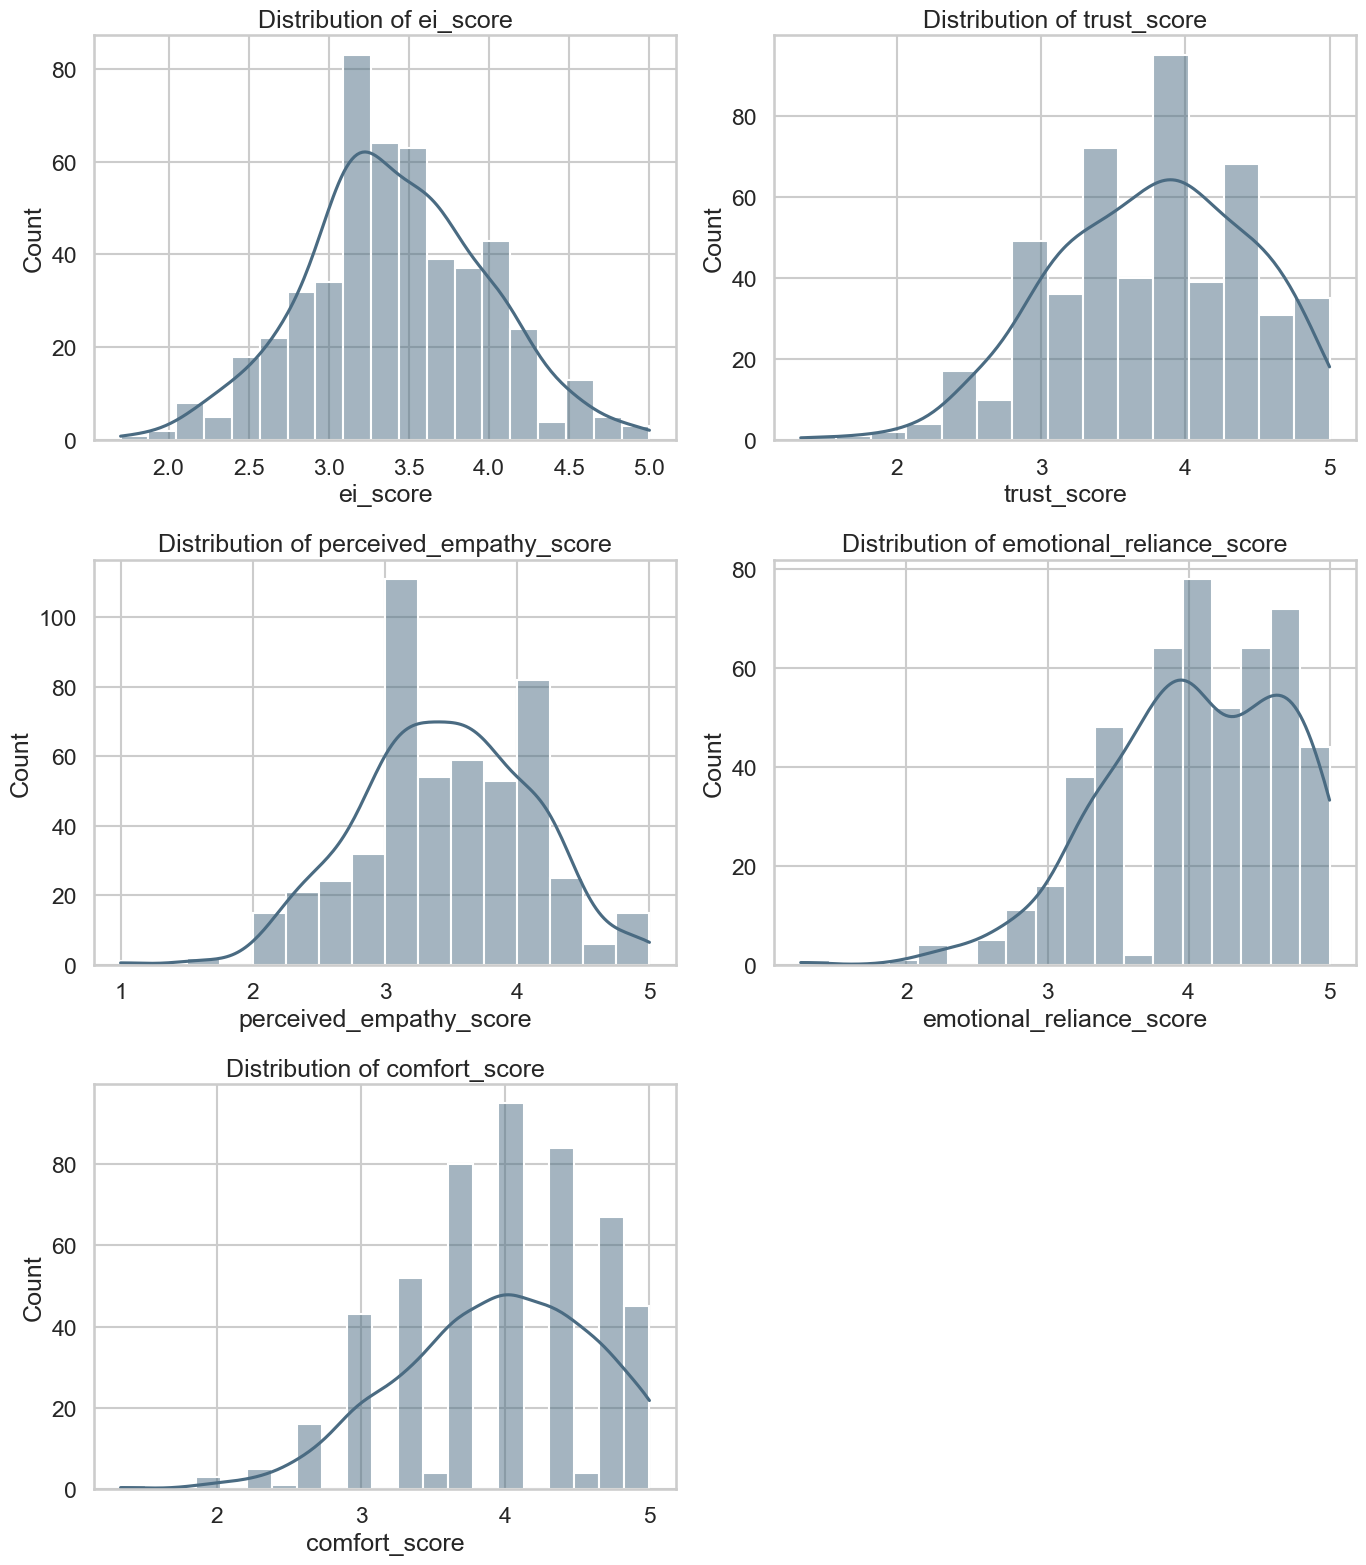

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(score_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4A6B82")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

axes[-1].axis("off") # Hide unused axis
plt.tight_layout()
plt.show()


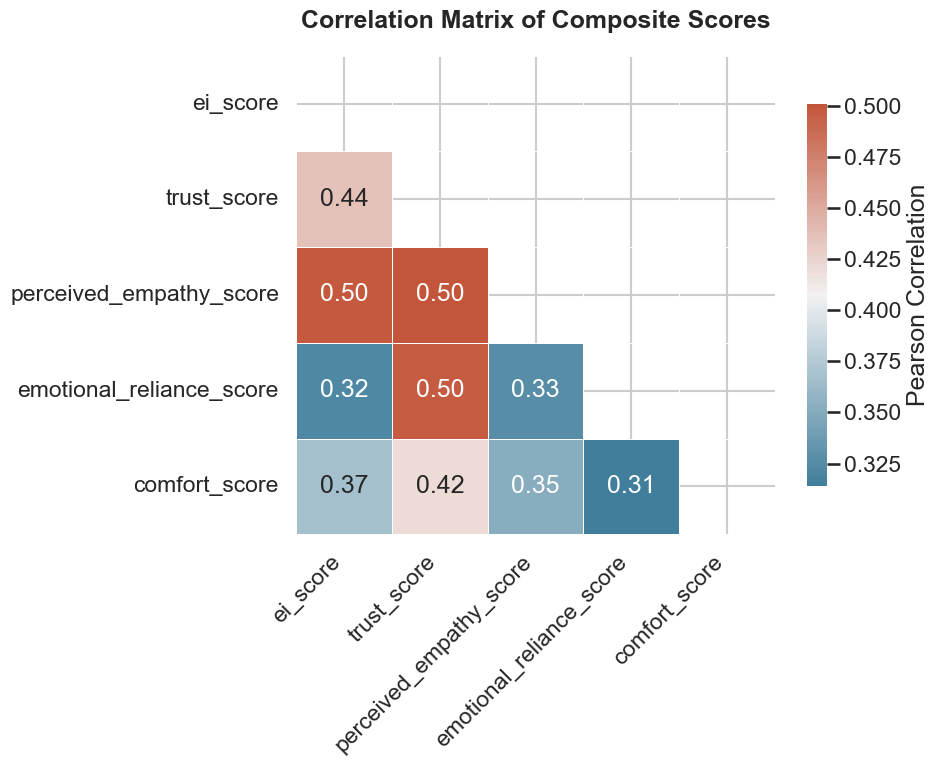

In [6]:
plt.figure(figsize=(10, 8))
corr = df[score_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    cmap=cmap, 
    fmt=".2f", 
    square=True, 
    linewidths=.5,
    cbar_kws={"shrink": .8, "label": "Pearson Correlation"}
)
plt.title("Correlation Matrix of Composite Scores", pad=20, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_8475/1320694623.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


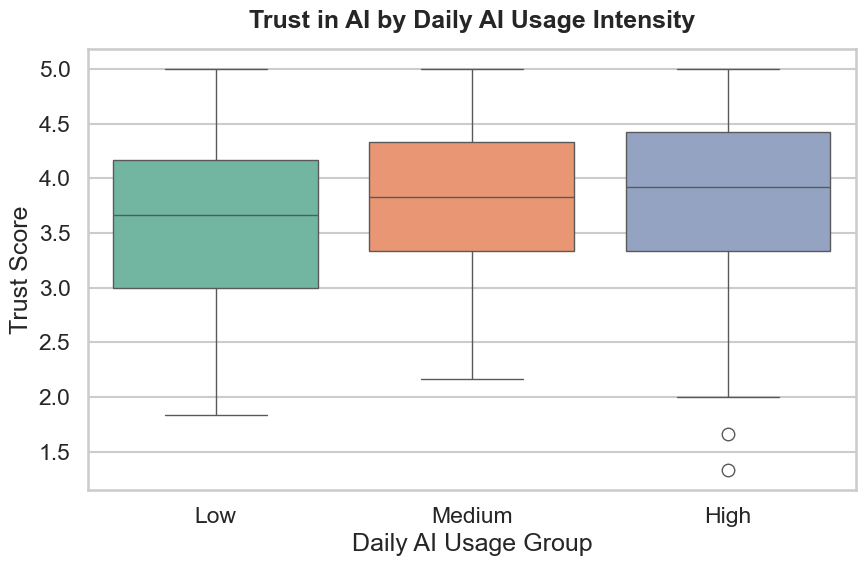

In [7]:
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df, 
    x="daily_ai_usage", 
    y="trust_score", 
    order=["Low", "Medium", "High"], 
    palette="Set2"
)
plt.title("Trust in AI by Daily AI Usage Intensity", pad=15, fontweight="bold")
plt.xlabel("Daily AI Usage Group")
plt.ylabel("Trust Score")
plt.tight_layout()
plt.show()


## Hypothesis Testing

We conduct statistical tests to formally evaluate our research questions.


### Test 1: Pearson Correlation (EI vs Trust)
We test whether higher Emotional Intelligence correlates with higher Trust in AI.


In [8]:
r, p_val = run_correlation(df, "ei_score", "trust_score")
print(f"Pearson Correlation: r = {r:.3f}")
print(f"P-value: {p_val:.5f}")

if p_val < 0.05:
    print("Decision: Reject H0. There is a statistically significant correlation between EI and Trust.")
else:
    print("Decision: Fail to reject H0. No significant correlation found.")


Pearson Correlation: r = 0.436
P-value: 0.00000
Decision: Reject H0. There is a statistically significant correlation between EI and Trust.


### Test 2: Gender Differences in Trust (Welch's t-test)
We check if Male and Female users report different trust scores. (Other category is excluded due to small sample size).


In [9]:
t_stat, p_val, means = run_t_test(df, "gender", "Male", "Female", "trust_score")
print("Welch Independent t-test:")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_val:.5f}")
for gender, mean_val in means.items():
    print(f"Mean Trust for {gender} users: {mean_val:.3f}")

if p_val < 0.05:
    print("Decision: Reject H0. There is a statistically significant gender difference in trust.")
else:
    print("Decision: Fail to reject H0. No significant gender difference in trust found.")


Welch Independent t-test:
t-statistic = -0.128
p-value = 0.89795
Mean Trust for Male users: 3.764
Mean Trust for Female users: 3.772
Decision: Fail to reject H0. No significant gender difference in trust found.


### Test 3: Trust Across AI Usage Groups (One-Way ANOVA)
We test if daily AI usage frequency has a significant impact on trust scores.


In [10]:
f_stat, p_val_anova, means_anova = run_anova(df, "daily_ai_usage", "trust_score")
print("One-Way ANOVA Results:")
print(f"F-statistic = {f_stat:.3f}")
print(f"p-value = {p_val_anova:.5f}")
print("Group Mean Trust Scores:")
for grp in ["Low", "Medium", "High"]:
    print(f"  {grp} AI Usage: {means_anova[grp]:.3f}")

if p_val_anova < 0.05:
    print("Decision: Reject H0. Mean trust scores differ significantly across daily AI usage groups.")
else:
    print("Decision: Fail to reject H0. No significant difference across usage groups.")


One-Way ANOVA Results:
F-statistic = 4.849
p-value = 0.00821
Group Mean Trust Scores:
  Low AI Usage: 3.625
  Medium AI Usage: 3.807
  High AI Usage: 3.862
Decision: Reject H0. Mean trust scores differ significantly across daily AI usage groups.


## Multiple Linear Regression Analysis

We fit an OLS multiple regression model to evaluate the predictive power of Emotional Intelligence on Trust in AI while controlling for demographics (Age, Gender) and behavioral intensity (Daily AI Usage).


In [11]:
# Fit model using OLS
formula = "trust_score ~ ei_score + age + C(daily_ai_usage) + C(gender)"
model = fit_regression(df, formula)
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            trust_score   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     22.16
Date:                Wed, 27 May 2026   Prob (F-statistic):           3.90e-23
Time:                        20:14:55   Log-Likelihood:                -458.14
No. Observations:                 500   AIC:                             930.3
Df Residuals:                     493   BIC:                             959.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## Formal Mediation Analysis (Baron & Kenny + Bootstrap)

To evaluate if the relationship between Emotional Intelligence (X) and Trust (Y) is mediated by Perceived Empathy (M), we apply the Baron & Kenny 4-step framework. Furthermore, we construct a 95% Confidence Interval for the indirect effect (ab) using non-parametric Bootstrap Resampling (1000 replications) and compute the Sobel test.


In [12]:
covariates = ["age", "C(daily_ai_usage)", "C(gender)"]
mediation_res = run_mediation(
    df=df, 
    x_col="ei_score", 
    m_col="perceived_empathy_score", 
    y_col="trust_score", 
    covariates=covariates,
    n_bootstrap=1000
)

# Output results
print("=== MEDIATION SUMMARY ===")
print(f"Total Effect (Path c):       {mediation_res['total_effect_c']:.4f} (p = {mediation_res['total_p']:.5f})")
print(f"X to Mediator (Path a):      {mediation_res['path_a']:.4f} (p = {mediation_res['path_a_p']:.5f})")
print(f"Mediator to Y (Path b):      {mediation_res['path_b']:.4f} (p = {mediation_res['path_b_p']:.5f})")
print(f"Direct Effect (Path c'):     {mediation_res['direct_effect_c_prime']:.4f} (p = {mediation_res['direct_p']:.5f})")
print(f"Indirect Effect (Path ab):   {mediation_res['indirect_effect_ab']:.4f}")
print("\n--- Significance Tests ---")
print(f"Sobel Z:                     {mediation_res['sobel_z']:.4f} (p = {mediation_res['sobel_p']:.5f})")
print(f"Bootstrap 95% CI (Percentile): [{mediation_res['ci_lower']:.4f}, {mediation_res['ci_upper']:.4f}]")

# Explain proportion
prop = mediation_res['indirect_effect_ab'] / mediation_res['total_effect_c']
print(f"Proportion of Total Effect Mediated: {prop:.1%}")


=== MEDIATION SUMMARY ===
Total Effect (Path c):       0.5259 (p = 0.00000)
X to Mediator (Path a):      0.5774 (p = 0.00000)
Mediator to Y (Path b):      0.3802 (p = 0.00000)
Direct Effect (Path c'):     0.3064 (p = 0.00000)
Indirect Effect (Path ab):   0.2195

--- Significance Tests ---
Sobel Z:                     7.0060 (p = 0.00000)
Bootstrap 95% CI (Percentile): [0.1596, 0.2882]
Proportion of Total Effect Mediated: 41.7%


## User Segmentation (K-Means Clustering)

We segment users into behavioral trust profiles using K-Means clustering on the five psychometric constructs. The features are standardized to ensure equal weight. A silhouette analysis is performed to find the optimal cluster size, and the profiles are mapped.


In [13]:
# Run K-Means and profile
df_clustered, profiles, sil_score, scaler, kmeans = perform_kmeans(
    df=df, 
    features=score_cols, 
    n_clusters=2
)

print(f"Silhouette Score: {sil_score:.3f}")
print("\nCluster Mean Composite Scores:")
print(profiles.round(2))


Silhouette Score: 0.273

Cluster Mean Composite Scores:
         ei_score  trust_score  perceived_empathy_score  \
cluster                                                   
0            3.72         4.20                     3.81   
1            3.08         3.29                     3.07   

         emotional_reliance_score  comfort_score  
cluster                                           
0                            4.39           4.27  
1                            3.67           3.59  


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


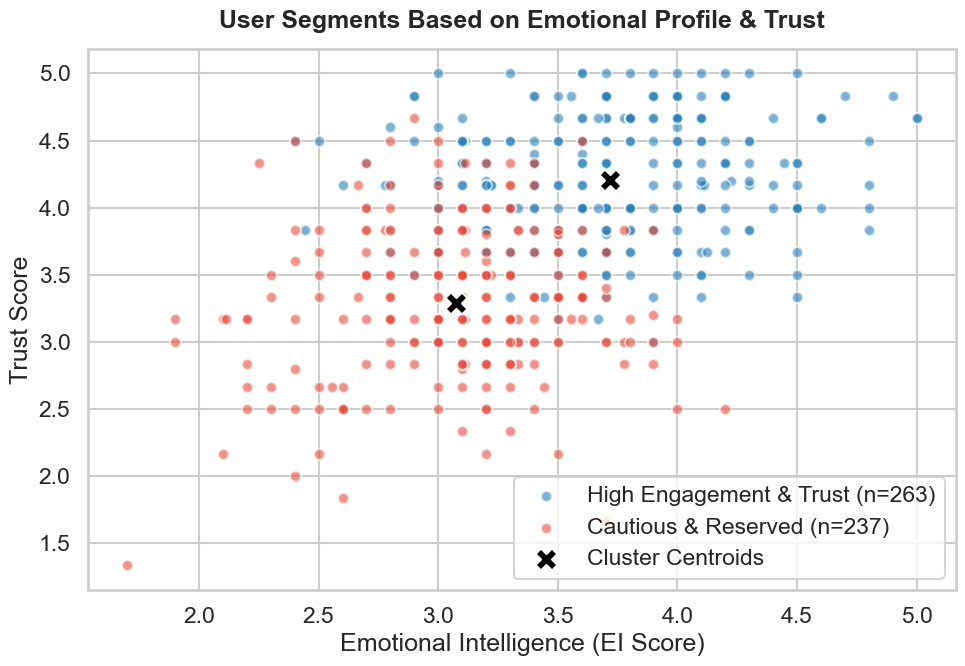

In [14]:
plt.figure(figsize=(10, 7))
colors = {0: "#2980B9", 1: "#E74C3C"}
labels = {
    0: f"High Engagement & Trust (n={len(df_clustered[df_clustered['cluster']==0])})", 
    1: f"Cautious & Reserved (n={len(df_clustered[df_clustered['cluster']==1])})"
}

for c in sorted(df_clustered["cluster"].unique()):
    sub = df_clustered[df_clustered["cluster"] == c]
    plt.scatter(
        sub["ei_score"], 
        sub["trust_score"], 
        label=labels[c], 
        color=colors[c], 
        alpha=0.6, 
        edgecolors="w", 
        s=60
    )

# Centroids in raw scale
centroids = df_clustered.groupby("cluster")[["ei_score", "trust_score"]].mean()
plt.scatter(
    centroids["ei_score"], 
    centroids["trust_score"], 
    color="black", 
    marker="X", 
    s=250, 
    label="Cluster Centroids", 
    edgecolors="w"
)

plt.title("User Segments Based on Emotional Profile & Trust", pad=15, fontweight="bold")
plt.xlabel("Emotional Intelligence (EI Score)")
plt.ylabel("Trust Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Strategic Insights and Product Implications

1. **Emotional Intelligence and Trust**: Higher EI is significantly associated with higher trust (r = 0.436, p < 0.001). This suggests that users with high emotional capabilities evaluate AI assistant interactions more favorably, possibly because they can manage interaction expectations or better interpret natural conversational cues.
2. **The Role of Perceived Empathy**: Mediation analysis reveals that perceived empathy acts as a strong psychological mechanism. Empathy explains 41.7% of the total effect of EI on trust (Indirect Effect ab = 0.220, Bootstrap 95% CI: [0.160, 0.288]). For AI designers, this indicates that creating systems perceived as empathetic is directly linked to higher trust.
3. **Daily Usage Impact**: Users with low daily AI exposure report significantly lower trust scores (ANOVA p = 0.008, regression coefficient beta = -0.258). Trust builds with experience and familiarity. Onboarding processes for new users should focus on expectations management.
4. **Targeted Design Profiles**: K-Means clustering highlights two user types:
   - *High Engagement & Trust (n=263)*: High score averages across all fronts.
   - *Cautious & Reserved (n=237)*: Significantly lower scores (Trust = 3.29, Comfort = 3.59). AI applications should provide greater transparency and simple controls for cautious users.


## Conclusion

This project demonstrates the application of behavioral data science to Human-AI Interaction. By applying psychometric validation (Cronbach's Alpha), hypothesis testing, multiple regression, formal mediation modeling, and user segmentation, we show that trust in Agentic AI is heavily influenced by emotional factors. 

This statistical workflow provides a blueprint for studying trust, usability, and perception in conversational and agentic product development.
